# 05 — Learning Model Predictive Control on a Repeated Double-Integrator Task

## Learning terminal safety and terminal value from successful executions

Classical stabilizing MPC uses carefully designed terminal ingredients:

$$
x_N\in\mathcal X_f,
\qquad
p(x_N).
$$

Learning Model Predictive Control (LMPC) asks a different question:

> If the same constrained task is executed repeatedly, can previous successful executions provide
> the terminal set and terminal value function for future executions?

LMPC answers it with two data objects:

$$
\boxed{\text{a safe set learned from successful state trajectories}}
$$

and

$$
\boxed{\text{a value / cost-to-go function learned from realized costs}}.
$$

For linear dynamics and convex constraints, the stored safe states can be convexified, leading to
a convex online MPC problem.

This notebook first develops those ideas geometrically in one dimension and then works through a
complete **double-integrator LMPC example**: a short-horizon MPC seed, repeated LMPC iterations,
and the resulting learning curve.


## Scope

This notebook covers Learning Model Predictive Control (LMPC) for a task that is executed
repeatedly from the same initial state. It builds the sampled safe set $SS^j$ from successful
trajectories and its convex hull $CS^j=\operatorname{conv}(SS^j)$, proves that both are control
invariant, learns a terminal value from stored roll-out costs-to-go through barycentric
coordinates, assembles the LMPC terminal constraint and terminal cost, and shows the resulting
iterative performance improvement. The ideas are developed first on a scalar integrator and then on
a complete double-integrator example, with derivations and numerical checks at each step.

The modelling assumptions are those under which the convex constructions are justified: a
deterministic task, known linear dynamics $x^+=Ax+Bu$, convex state and input constraints, and a
convex stage cost. Only the terminal ingredients (stored safe states with their continuation inputs
and costs-to-go) are learned from data; the plant model is not.

The LMPC framework is developed in U. Rosolia and F. Borrelli, “Learning Model Predictive Control
for Iterative Tasks. A Data-Driven Control Framework,” *IEEE Transactions on Automatic Control*,
63(7), 2018. For terminal sets, terminal costs and invariance in classical MPC, see F. Borrelli,
A. Bemporad and M. Morari, *Predictive Control for Linear and Hybrid Systems*, Cambridge University
Press, 2017.


## Learning objectives

After completing this notebook, you should be able to:

1. define an iterative/repetitive control task;
2. define a successful iteration and a target set $\mathcal O$;
3. construct the sampled safe set $SS^j$;
4. prove its one-step control-invariance property by replaying stored inputs;
5. construct the convex safe set $CS^j=\operatorname{conv}(SS^j)$;
6. prove why convexification preserves control invariance for linear dynamics and convex
constraints;
7. compute stored roll-out cost-to-go values;
8. distinguish the sampled value function from its convex extension;
9. formulate barycentric coordinates and the convex terminal value as a linear program;
10. write the complete LMPC finite-horizon problem;
11. explain why LMPC terminal ingredients play the same role as terminal ingredients in
stabilizing MPC;
12. write the double-integrator stage cost used here, including its $\ell_1$ term;
13. understand the epigraph formulation of that $\ell_1$ penalty;
14. generate a feasible seed trajectory with short-horizon MPC;
15. run repeated LMPC iterations and interpret the learning curve;
16. explain what is actually “learned”;
17. understand why different initial safe trajectories need not universally produce the same final
solution;
18. distinguish LMPC from reinforcement learning and iterative learning control.


In [1]:
from pathlib import Path
import sys
import time
import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial import ConvexHull

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

from advanced_mpc_lmpc.lmpc import (
    stage_cost,
    trajectory_cost_to_go,
    solve_ftocp_l1,
    convex_safe_value,
    LMPCController,
)

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
})


## Table of Contents

- **[Part I — Repetitive tasks](#part-1)** — I.1 Iteration index versus time index · I.2 Target set and successful iteration · I.3 What does “safe” mean here?
- **[Part II — Sampled safe sets](#part-2)** — II.1 Sampled safe set · II.2 Why the sampled safe set is control invariant · II.3 The important quantifier
- **[Part III — Convex safe sets](#part-3)** — III.1 Why convexify? · III.2 Barycentric coordinates · III.3 Why the convex safe set is control invariant
- **[Part IV — Learning a terminal value function](#part-4)** — IV.1 Roll-out cost-to-go · IV.2 Sampled value function · IV.3 Convex terminal value
- **[Part V — A one-dimensional example](#part-5)** — V.1 Constrained integrator · V.2 How to read this figure
- **[Part VI — Why the learned value can act like a terminal Lyapunov function](#part-6)** — VI.1 Data recursion · VI.2 Learned-value decrease
- **[Part VII — The LMPC online optimization](#part-7)** — VII.1 Finite-horizon problem · VII.2 Geometric meaning · VII.3 Recursive feasibility: shifted-sequence argument
- **[Part VIII — The double-integrator task](#part-8)** — VIII.1 Numerical model · VIII.2 Stage cost · VIII.3 Epigraph formulation of the $\ell_1$ term · VIII.4 Choice of the short horizon
- **[Part IX — Long-horizon reference](#part-9)** — IX.1 Reference computation
- **[Part X — Generate the initial feasible trajectory with short-horizon MPC](#part-10)** — X.1 A feasible but suboptimal seed · X.2 Compare complete task costs
- **[Part XI — Initialize the LMPC database](#part-11)** — XI.1 Store the seed · XI.2 Inspect one stored continuation
- **[Part XII — Numerical check of convex-safe-set invariance](#part-12)** — XII.1 Construct a convex combination
- **[Part XIII — First LMPC optimization](#part-13)** — XIII.1 Solve from the repeated initial state · XIII.2 Why a sparse barycentric representation exists
- **[Part XIV — Repeated LMPC iterations](#part-14)** — XIV.1 Iteration algorithm · XIV.2 Limited active data for numerical scalability
- **[Part XV — Learning curves](#part-15)** — XV.1 Closed-loop cost versus iteration · XV.2 What is guaranteed and what is observed?
- **[Part XVI — How the trajectories change](#part-16)** — XVI.1 Phase-plane evolution · XVI.2 Control evolution
- **[Part XVII — Safe-set growth in the state plane](#part-17)** — XVII.1 Convex hull of accumulated successful data · XVII.2 Safe-set geometry is only half of the learning
- **[Part XVIII — Stored cost-to-go values](#part-18)** — XVIII.1 Backward recursion
- **[Part XIX — What exactly is learned?](#part-19)** — XIX.1 The plant model is not learned here · XIX.2 LMPC is not DQN · XIX.3 LMPC versus iterative learning control
- **[Part XX — Do different initializations converge to the same solution?](#part-20)** — XX.1 A natural question
- **[Part XXI — Time-varying safe sets and data growth](#part-21)** — XXI.1 Why stored-data management matters
- **[Part XXII — What the experiment establishes](#part-22)** — XXII.1 Supported conclusions · XXII.2 Unsupported conclusions
- **[Part XXIII — Common pitfalls](#part-23)** — XXIII.1 Pitfall: every stored state is optimal · XXIII.2 Pitfall: the convex hull is always safe · XXIII.3 Pitfall: the terminal value is a neural network · XXIII.4 Pitfall: safe-set growth alone explains learning · XXIII.5 Pitfall: the long-horizon reference proves the exact infinite-horizon optimum · XXIII.6 Pitfall: a three-step horizon only sees three steps ahead · XXIII.7 Pitfall: LMPC is reinforcement learning simply because it learns from data
- **[Part XXIV — Check your understanding](#part-24)**
- **[Part XXV — Exercises](#part-25)**
- **[Part XXVI — References](#part-26)**


<a id="part-1"></a>
# Part I — Repetitive tasks

## I.1 Iteration index versus time index

LMPC has two different indices.

- $j$ denotes the **iteration** of the repeated task.
- $t$ denotes **time within one iteration**.

A trajectory from iteration $j$ is written

$$
x^j[0],u^j[0],x^j[1],u^j[1],\ldots,x^j[T_j].
$$

The plant is

$$
x^j[t+1]
=
f\!\left(x^j[t],u^j[t]\right).
$$

For the linear case developed later,

$$
f(x,u)=Ax+Bu.
$$

The task is repeated from the same initial condition

$$
x^j[0]=x_S.
$$

This repeated-task structure is fundamental.


## I.2 Target set and successful iteration

Let $\mathcal O$ be the target set.

An iteration is **successful** if all state/input constraints are respected and

$$
x^j[T_j]\in\mathcal O.
$$

The safe-set construction uses successful executions only.

In both examples of this notebook, the scalar integrator of Part V and the double integrator of
Part VIII,

$$
\boxed{
\mathcal O=\{0\}.
}
$$


## I.3 What does “safe” mean here?

A stored state is called safe because there exists a **known admissible continuation to the
target**: replay the remainder of a previously successful trajectory.

That is a model/task-specific notion.

It is not a general real-world certificate against unmodeled disturbances, perception errors, or
model mismatch.


<a id="part-2"></a>
# Part II — Sampled safe sets

## II.1 Sampled safe set

After successful iterations $i=0,\ldots,j$, define the **sampled safe set**

$$
\boxed{
SS^j
=
\left(
\bigcup_{i=0}^{j}
\bigcup_{t=0}^{T_i}
\{x^i[t]\}
\right)
\cup
\mathcal O.
}
$$

It is a collection of previously visited successful states.

It is finite for finitely many finite trajectories and grows as new successful executions are
added.


## II.2 Why the sampled safe set is control invariant

Take a stored nonterminal point

$$
x=x^i[t]\in SS^j.
$$

The corresponding stored input $u^i[t]$ is admissible and produces

$$
f(x^i[t],u^i[t])=x^i[t+1]\in SS^j.
$$

Therefore

$$
\boxed{
x\in SS^j
\Longrightarrow
\exists u\in\mathcal U:
f(x,u)\in SS^j.
}
$$

At the target set $\mathcal O$, one assumes an admissible target controller that keeps the state in
$\mathcal O$.

The stored trajectory itself provides the continuation.


## II.3 The important quantifier

The statement is

$$
\forall x\in SS^j,\quad
\exists u\in\mathcal U.
$$

It does **not** say that one single input works for every state.

Each sampled state may use a different stored continuation input.


<a id="part-3"></a>
# Part III — Convex safe sets

## III.1 Why convexify?

A terminal constraint

$$
x_N\in SS^j
$$

would force the prediction to end exactly on one stored sample.

For the linear/convex setting, we therefore introduce the **convex safe set**

$$
\boxed{
CS^j=\operatorname{conv}(SS^j).
}
$$

This fills in the space between stored safe states while retaining a convex optimization
structure.


## III.2 Barycentric coordinates

Let the stored safe states be $s_1,\ldots,s_M$.

A point $x\in CS^j$ can be represented as

$$
\boxed{
x=\sum_{r=1}^{M}\lambda_rs_r
}
$$

with

$$
\lambda_r\ge0,
\qquad
\sum_{r=1}^{M}\lambda_r=1.
$$

If we stack the stored safe states as the **rows** of a matrix $S\in\mathbb R^{M\times n}$, where
$n$ is the state dimension,

$$
S=
\begin{bmatrix}
s_1^\top\\
\vdots\\
s_M^\top
\end{bmatrix},
$$

then

$$
\boxed{
x=S^\top\lambda,
\qquad
\lambda\ge0,
\qquad
\mathbf1^\top\lambda=1.
}
$$

**Convention.** The stored safe states are the *rows* of $S$, both in the formulas and in the code
(`convex_safe_value` and `LMPCController.safe_data()` use one stored state per row). This is why
the transpose appears in $x=S^\top\lambda$, and why the LMPC terminal constraint of Part VII reads
$x_N=S^\top\lambda$, $\lambda\ge0$, $\mathbf1^\top\lambda=1$.


## III.3 Why the convex safe set is control invariant

Assume:

- $x^+=Ax+Bu$;
- $\mathcal X$ and $\mathcal U$ are convex;
- every safe point $s_r$ has a known admissible continuation input $u_r^{\mathrm{safe}}$ and safe
successor $s_r^+$.

For

$$
x=\sum_r\lambda_rs_r,
$$

choose

$$
u=\sum_r\lambda_ru_r^{\mathrm{safe}}.
$$

Then, by linearity,

$$
x^+
=
\sum_r\lambda_r
\left(
As_r+Bu_r^{\mathrm{safe}}
\right)
=
\sum_r\lambda_rs_r^+.
$$

Because the input set is convex, $u\in\mathcal U$.
Because the safe successors remain in the safe set,

$$
x^+\in CS^j.
$$

Hence

$$
\boxed{
CS^j
\text{ is control invariant}
}
$$

under these assumptions.


### What breaks outside these assumptions?

For nonlinear dynamics,

$$
f\!\left(
\sum_r\lambda_rs_r,
\sum_r\lambda_ru_r
\right)
$$

is generally not equal to

$$
\sum_r\lambda_rf(s_r,u_r).
$$

Likewise, convex combinations can violate nonconvex constraints.

So convexifying stored trajectories for a nonlinear task requires separate justification.


<a id="part-4"></a>
# Part IV — Learning a terminal value function

## IV.1 Roll-out cost-to-go

For a successful iteration $i$,

$$
\boxed{
J_t^i
=
\sum_{k=t}^{T_i-1}
h\!\left(x^i[k],u^i[k]\right).
}
$$

At the target,

$$
J_{T_i}^i=0.
$$

This is the realized remaining cost if the stored continuation is replayed.


## IV.2 Sampled value function

If the same state appears multiple times, we keep the best stored cost-to-go:

$$
\boxed{
V^j(x)
=
\min_{\substack{
i,t\\
x^i[t]=x
}}
J_t^i.
}
$$

On the target,

$$
V^j(x)=0,
\qquad
x\in\mathcal O.
$$

The difficulty is that this function is defined only at sampled states.


## IV.3 Convex terminal value

We extend the sampled data to the convex safe set using

$$
\boxed{
V_c^j(x)
=
\min_{\lambda}
\sum_{r=1}^{M}\lambda_rV_r
}
$$

subject to

$$
S^\top\lambda=x,
\qquad
\mathbf1^\top\lambda=1,
\qquad
\lambda\ge0.
$$

Here $V_r$ is the cost-to-go stored with the safe state $s_r$ (row $r$ of $S$).

For fixed stored data, this is a **linear program in $\lambda$**.

Geometrically, it constructs the lower convex envelope of the stored state/value samples.


<a id="part-5"></a>
# Part V — A one-dimensional example

## V.1 Constrained integrator

Consider the scalar integrator

$$
x[t+1]=x[t]+u[t],
$$

with

$$
x\in[-5,5],
\qquad
u\in[-1,1],
$$

target $\mathcal O=\{0\}$, and

$$
h(x,u)=x^2+0.1u^2.
$$

Two successful iterations are

$$
4\rightarrow3\rightarrow2\rightarrow1\rightarrow0
$$

and

$$
-3\rightarrow-2\rightarrow-1\rightarrow0.
$$

Therefore

$$
SS^1=\{-3,-2,-1,0,1,2,3,4\},
$$

and

$$
\boxed{
CS^1=[-3,4].
}
$$


In [2]:
def scalar_cost_to_go(states, inputs):
    states = np.asarray(states, float)
    inputs = np.asarray(inputs, float)

    J = np.zeros(len(states))
    for k in range(len(inputs) - 1, -1, -1):
        J[k] = states[k]**2 + 0.1*inputs[k]**2 + J[k+1]
    return J


x_pos = np.array([4., 3., 2., 1., 0.])
u_pos = -np.ones(4)

x_neg = np.array([-3., -2., -1., 0.])
u_neg = np.ones(3)

J_pos = scalar_cost_to_go(x_pos, u_pos)
J_neg = scalar_cost_to_go(x_neg, u_neg)

sample_x = np.r_[x_neg[:-1], x_pos]
sample_V = np.r_[J_neg[:-1], J_pos]

order = np.argsort(sample_x)
sample_x = sample_x[order]
sample_V = sample_V[order]

print("sampled state/value pairs:")
for x, v in zip(sample_x, sample_V):
    print(f"x={x:4.1f}   V={v:6.2f}")


sampled state/value pairs:
x=-3.0   V= 14.30
x=-2.0   V=  5.20
x=-1.0   V=  1.10
x= 0.0   V=  0.00
x= 1.0   V=  1.10
x= 2.0   V=  5.20
x= 3.0   V= 14.30
x= 4.0   V= 30.40


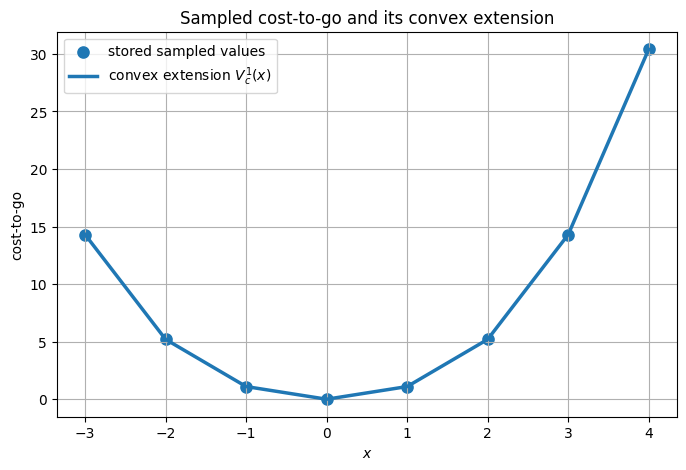

In [3]:
grid_1d = np.linspace(-3.0, 4.0, 141)

Vc = []
for xq in grid_1d:
    value, lam, success = convex_safe_value(
        np.array([xq]),
        sample_x[:, None],
        sample_V,
    )
    if not success:
        raise RuntimeError("Unexpected LP infeasibility inside the convex safe set.")
    Vc.append(value)

Vc = np.asarray(Vc)

plt.figure()
plt.scatter(sample_x, sample_V, s=65, label="stored sampled values")
plt.plot(grid_1d, Vc, linewidth=2.5, label=r"convex extension $V_c^1(x)$")
plt.xlabel(r"$x$")
plt.ylabel("cost-to-go")
plt.title("Sampled cost-to-go and its convex extension")
plt.legend()
plt.show()


## V.2 How to read this figure

The dots are values known directly from previous executions.

The continuous curve is **not new measured data**.

For each intermediate $x$, it solves the barycentric LP:

> What is the cheapest convex combination of stored state/value pairs that represents this state?

In one dimension this produces a convex, piecewise-affine lower envelope.

A stored point above that lower envelope would be dominated and would not necessarily be reproduced
exactly by $V_c^j$.


In [4]:
x_query = np.array([2.5])

value_25, lambda_25, ok_25 = convex_safe_value(
    x_query,
    sample_x[:, None],
    sample_V,
)

active = np.where(lambda_25 > 1e-8)[0]

print("query state:", x_query.item())
print("convex terminal value:", value_25)
print("sum(lambda):", lambda_25.sum())
print("reconstructed state:", (sample_x[:, None].T @ lambda_25).item())
print("\nactive barycentric weights:")

for idx in active:
    print(
        f"  x={sample_x[idx]:4.1f}, "
        f"V={sample_V[idx]:6.2f}, "
        f"lambda={lambda_25[idx]:.4f}"
    )


query state: 2.5
convex terminal value: 9.75
sum(lambda): 1.0
reconstructed state: 2.5

active barycentric weights:
  x= 2.0, V=  5.20, lambda=0.5000
  x= 3.0, V= 14.30, lambda=0.5000


<a id="part-6"></a>
# Part VI — Why the learned value can act like a terminal Lyapunov function

## VI.1 Data recursion

For a stored safe state $s_r$,

$$
J_r
=
h(s_r,u_r)
+
J_r^+.
$$

For

$$
x=\sum_r\lambda_rs_r,
$$

use

$$
u=\sum_r\lambda_ru_r.
$$

Then

$$
x^+=\sum_r\lambda_rs_r^+.
$$


## VI.2 Learned-value decrease

Convexity of $h$ gives

$$
h(x,u)
\le
\sum_r\lambda_rh(s_r,u_r).
$$

By definition of the convex terminal value,

$$
V_c^j(x^+)
\le
\sum_r\lambda_rJ_r^+.
$$

Therefore

$$
h(x,u)+V_c^j(x^+)
\le
\sum_r\lambda_r
\left[
h(s_r,u_r)+J_r^+
\right].
$$

Using

$$
h(s_r,u_r)+J_r^+=J_r,
$$

we obtain

$$
\boxed{
V_c^j(x^+)-V_c^j(x)
\le
-h(x,u).
}
$$

This has the same structural role as the terminal-cost decrease condition in stabilizing MPC.

Here the terminal value is built from data rather than a Riccati equation.


<a id="part-7"></a>
# Part VII — The LMPC online optimization

## VII.1 Finite-horizon problem

At the current state, solve

$$
\begin{aligned}
\min_{\{u_k\},\lambda}\quad&
\sum_{k=0}^{N-1}h(x_k,u_k)
+
\sum_{r=1}^{M}\lambda_rV_r
\\
\text{s.t.}\quad&
x_{k+1}=Ax_k+Bu_k,
\\
&
x_k\in\mathcal X,
\quad
u_k\in\mathcal U,
\\
&
x_N=S^\top\lambda,
\\
&
\lambda\ge0,
\quad
\mathbf1^\top\lambda=1.
\end{aligned}
$$

The last two constraints and the learned terminal cost are the data-driven terminal ingredients.


## VII.2 Geometric meaning

The equality

$$
x_N=S^\top\lambda
$$

means the optimizer may reconnect to **any point in the convex hull of successful experience**.

The cost

$$
\lambda^\top V
$$

then tells it how expensive the stored continuation from that terminal representation is.

So LMPC learns both terminal **geometry** and terminal **value**.


## VII.3 Recursive feasibility: shifted-sequence argument

Suppose

$$
x_N^\star
=
\sum_r\lambda_r^\star s_r.
$$

At the next time, shift the optimized controls and append

$$
\boxed{
u_N^{\mathrm{safe}}
=
\sum_r
\lambda_r^\star
u_r^{\mathrm{safe}}.
}
$$

Then

$$
\begin{aligned}
x_{N+1}
&=
A\sum_r\lambda_r^\star s_r
+
B\sum_r\lambda_r^\star u_r^{\mathrm{safe}}
\\
&=
\sum_r\lambda_r^\star s_r^+.
\end{aligned}
$$

The new terminal state remains in the convex safe set.

This is the LMPC counterpart of the terminal-set shifted-sequence proof.


<a id="part-8"></a>
# Part VIII — The double-integrator task

## VIII.1 Numerical model

We now apply LMPC to the discrete-time double integrator with state $x=[x_1,x_2]^\top$
(position and velocity) and

$$
A=
\begin{bmatrix}
1&1\\
0&1
\end{bmatrix},
\qquad
B=
\begin{bmatrix}
0\\
1
\end{bmatrix}.
$$

The initial condition is

$$
x_S=
\begin{bmatrix}
-15\\0
\end{bmatrix}.
$$

The box constraints are

$$
|x_i|\le15,
\qquad
|u|\le5.
$$


In [5]:
A = np.array([
    [1.0, 1.0],
    [0.0, 1.0],
])

B = np.array([
    [0.0],
    [1.0],
])

x_start = np.array([-15.0, 0.0])

x_lower = np.array([-15.0, -15.0])
x_upper = np.array([ 15.0,  15.0])

u_lower = np.array([-5.0])
u_upper = np.array([ 5.0])

print("A =")
print(A)
print("\nB =")
print(B)


A =
[[1. 1.]
 [0. 1.]]

B =
[[0.]
 [1.]]


## VIII.2 Stage cost

We use the weights

$$
Q=I,
\qquad
Q_1=0.01I,
\qquad
R=1.
$$

The stage cost is

$$
\boxed{
h(x,u)
=
x^\top Qx
+
u^\top Ru
+
\|Q_1x\|_1.
}
$$

The small $\ell_1$ term makes $h$ convex but not purely quadratic. The value-decrease argument of
Part VI needs only convexity of $h$, and VIII.3 shows that the online problem remains a QP.


In [6]:
Q = np.eye(2)
Q1 = 0.01 * Q
R = np.array([[1.0]])

print("stage cost at x=[-15,0], u=0:")
print(stage_cost(x_start, np.array([0.0]), Q, R, Q1))


stage cost at x=[-15,0], u=0:
225.15


## VIII.3 Epigraph formulation of the $\ell_1$ term

Let

$$
z_k=Q_1x_k.
$$

Introduce

$$
e_{i,k}\ge0
$$

with

$$
z_{i,k}\le e_{i,k},
\qquad
-z_{i,k}\le e_{i,k}.
$$

Minimizing $\sum_i e_{i,k}$ forces

$$
e_{i,k}=|z_{i,k}|.
$$

Thus the $\ell_1$ term can be represented using linear inequalities and a linear contribution to
the objective.

The overall optimization therefore remains a convex QP.


## VIII.4 Choice of the short horizon

The seed controller of Part X uses the deliberately short horizon

$$
\boxed{
N_{\mathrm{MPC}}=3.
}
$$

LMPC uses the same value, $N_{\mathrm{LMPC}}=3$ (Part XIII). The two controllers share the stage
cost and the constraints and differ only in their terminal ingredients: the seed MPC has no
terminal cost or terminal constraint, while LMPC adds the learned terminal set and value.

The short horizon is what leaves room for learning. With a substantially longer horizon, plain MPC
already comes very close to the long-horizon reference on this task, and there would be little left
to improve; Exercise 7 explores the effect of the horizon.


<a id="part-9"></a>
# Part IX — Long-horizon reference

## IX.1 Reference computation

A common benchmark is a single open-loop problem with a very long finite horizon, for example

$$
N=1000,
$$

used as a numerical proxy for an infinite-time optimum.

Here we keep the computation lightweight and solver-independent: we check horizon convergence and
use a shorter horizon once the numerical result has stabilized.


In [7]:
reference_horizons = [10, 15, 20]
reference_solutions = {}

for N_ref in reference_horizons:
    sol_ref = solve_ftocp_l1(
        A, B, Q, R, Q1,
        N=N_ref,
        x0=x_start,
        x_lower=x_lower,
        x_upper=x_upper,
        u_lower=u_lower,
        u_upper=u_upper,
    )

    if not sol_ref.success:
        raise RuntimeError(sol_ref.message)

    reference_solutions[N_ref] = sol_ref

    print(
        f"N={N_ref:2d}: "
        f"cost={sol_ref.objective:.9f}, "
        f"terminal norm={np.linalg.norm(sol_ref.X[-1]):.3e}"
    )


N=10: cost=673.675953310, terminal norm=3.027e-02
N=15: cost=673.676653450, terminal norm=7.474e-13
N=20: cost=673.676653450, terminal norm=2.420e-09


The numerical value has essentially converged in this example, so we use

$$
N_{\mathrm{ref}}=20
$$

as the **long-horizon reference** for the rest of the notebook.

This is a numerical reference, not a proof that a finite horizon equals the exact infinite-horizon
optimum.


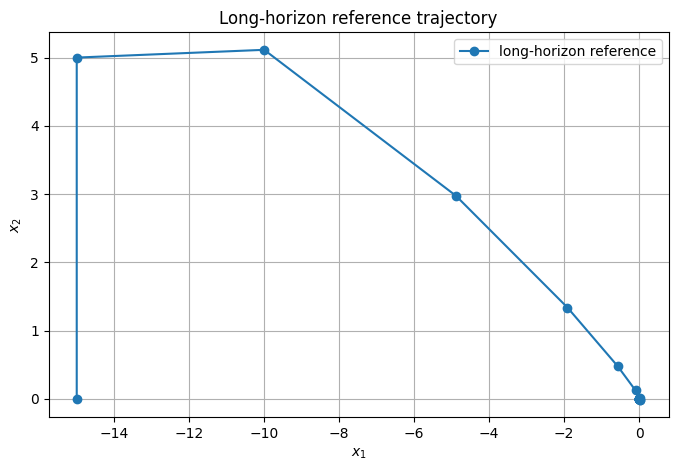

reference cost: 673.6766534499407


In [8]:
reference = reference_solutions[20]
reference_cost = reference.objective

plt.figure()
plt.plot(reference.X[:, 0], reference.X[:, 1], "-o", label="long-horizon reference")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Long-horizon reference trajectory")
plt.legend()
plt.show()

print("reference cost:", reference_cost)


<a id="part-10"></a>
# Part X — Generate the initial feasible trajectory with short-horizon MPC

## X.1 A feasible but suboptimal seed

LMPC needs at least one successful trajectory.

We generate it with ordinary receding-horizon MPC, without terminal cost or terminal constraint
(VIII.4), and

$$
N_{\mathrm{MPC}}=3.
$$

The trajectory is feasible but suboptimal.
It initializes the safe set and the stored cost-to-go.


In [9]:
def close_double_integrator_exactly(X_list, U_list, tol=1e-5):
    # Numerical completion used only to make the stored trajectory end
    # exactly at O={0}.
    #
    # For A=[[1,1],[0,1]], B=[[0],[1]], from x=[p,v]:
    #
    #   u0 = -p - 2 v
    #   u1 =  p + v
    #
    # gives x_{k+2}=0.
    x = np.asarray(X_list[-1], float).copy()

    if np.linalg.norm(x) > tol:
        raise ValueError("terminal bridge requested too far from the target")

    p, v = x
    bridge = [
        np.array([-p - 2.0*v]),
        np.array([ p + v]),
    ]

    for u in bridge:
        if np.any(u < u_lower - 1e-9) or np.any(u > u_upper + 1e-9):
            raise ValueError("terminal bridge violates the input bounds")

        x = A @ x + B @ u

        if np.any(x < x_lower - 1e-9) or np.any(x > x_upper + 1e-9):
            raise ValueError("terminal bridge violates the state bounds")

        U_list.append(u.copy())
        X_list.append(x.copy())

    X_list[-1] = np.zeros(2)

    return X_list, U_list


def run_short_horizon_mpc_seed(
    x0,
    *,
    N=3,
    stop_tol=1e-6,
    max_steps=100,
):
    x = np.asarray(x0, float).copy()

    X = [x.copy()]
    U = []

    for _ in range(max_steps):
        if np.linalg.norm(x) <= stop_tol:
            break

        sol = solve_ftocp_l1(
            A, B, Q, R, Q1,
            N=N,
            x0=x,
            x_lower=x_lower,
            x_upper=x_upper,
            u_lower=u_lower,
            u_upper=u_upper,
        )

        if not sol.success:
            raise RuntimeError(sol.message)

        u = sol.U[0].copy()
        x = A @ x + B @ u

        U.append(u)
        X.append(x.copy())
    else:
        raise RuntimeError("short-horizon MPC did not approach the target")

    X, U = close_double_integrator_exactly(X, U, tol=1e-5)

    return np.asarray(X), np.asarray(U)


X_seed, U_seed = run_short_horizon_mpc_seed(x_start)

J_seed = trajectory_cost_to_go(
    X_seed,
    U_seed,
    Q,
    R,
    Q1,
)

print("seed trajectory length:", len(U_seed), "steps")
print("seed terminal state:", X_seed[-1])
print("seed closed-loop cost:", J_seed[0])
print("long-horizon reference cost:", reference_cost)
print("seed performance gap:", J_seed[0] - reference_cost)


seed trajectory length: 26 steps
seed terminal state: [0. 0.]
seed closed-loop cost: 693.9923723414192
long-horizon reference cost: 673.6766534499407
seed performance gap: 20.315718891478582


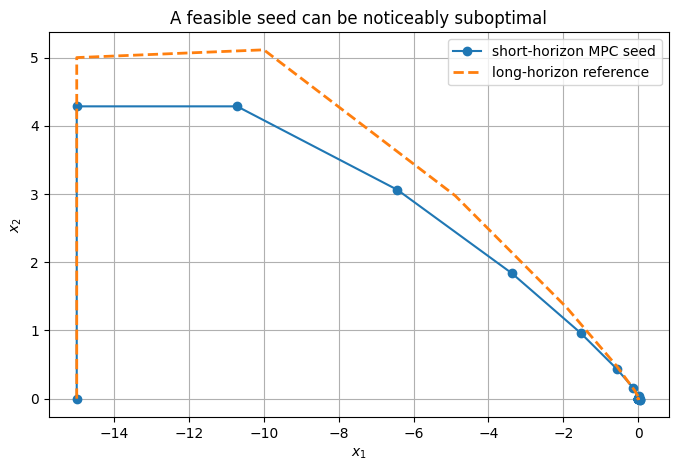

In [10]:
plt.figure()
plt.plot(X_seed[:, 0], X_seed[:, 1], "-o", label="short-horizon MPC seed")
plt.plot(reference.X[:, 0], reference.X[:, 1], "--", linewidth=2,
         label="long-horizon reference")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("A feasible seed can be noticeably suboptimal")
plt.legend()
plt.show()


## X.2 Compare complete task costs

The open-loop objective of one $N=3$ solve contains only three future stages.

The **seed closed-loop task cost** accumulates the complete repeated MPC execution until the target
is reached.

Those are different quantities.

Learning curves should compare complete iteration costs.


<a id="part-11"></a>
# Part XI — Initialize the LMPC database

## XI.1 Store the seed

The controller stores:

- successful states;
- applied inputs;
- backward cost-to-go values.

The target $x=0$ is represented explicitly with zero terminal cost.


In [11]:
N_LMPC = 3

lmpc = LMPCController(
    A, B, Q, R,
    N=N_LMPC,
    Q1=Q1,
    x_lower=x_lower,
    x_upper=x_upper,
    u_lower=u_lower,
    u_upper=u_upper,
    target=np.zeros(2),
)

lmpc.add_trajectory(X_seed, U_seed)

S_seed, V_seed, Usafe_seed, next_seed = lmpc.safe_data()

print("stored successful trajectories:", len(lmpc.trajectories))
print("safe-state samples:", len(S_seed))
print("stored seed cost:", lmpc.iteration_costs[0])


stored successful trajectories: 1
safe-state samples: 27
stored seed cost: 693.9923723414192


## XI.2 Inspect one stored continuation

Every nonterminal safe point has a continuation input, successor safe point, and cost-to-go.

That makes the invariance statement constructive.


In [12]:
r = 5

print("safe state =", S_seed[r])
print("stored safe input =", Usafe_seed[r])

r_next = next_seed[r]

print("stored successor =", S_seed[r_next])
print(
    "dynamics residual =",
    A @ S_seed[r] + B @ Usafe_seed[r] - S_seed[r_next]
)
print("cost-to-go =", V_seed[r])


safe state = [-3.369286  1.836434]
stored safe input = [-0.874495]
stored successor = [-1.532852  0.96194 ]
dynamics residual = [0. 0.]
cost-to-go = 19.799092676358153


<a id="part-12"></a>
# Part XII — Numerical check of convex-safe-set invariance

## XII.1 Construct a convex combination

Choose several stored safe points and convex weights.

Then compare the successor computed from the convex-combination state/input with the convex
combination of stored successors.


In [13]:
chosen = np.array([2, 5, 8, 12])
lam_demo = np.array([0.10, 0.25, 0.30, 0.35])

x_demo = lam_demo @ S_seed[chosen]
u_demo = lam_demo @ Usafe_seed[chosen]

successor_indices = next_seed[chosen]

x_plus_from_data = lam_demo @ S_seed[successor_indices]
x_plus_from_dynamics = A @ x_demo + B @ u_demo

print("lambda sum:", lam_demo.sum())
print("convex-combination state:", x_demo)
print("convex-combination input:", u_demo)
print("successor from dynamics:", x_plus_from_dynamics)
print("successor from stored successors:", x_plus_from_data)
print("difference:", x_plus_from_dynamics - x_plus_from_data)


lambda sum: 0.9999999999999999
convex-combination state: [-2.36938  0.93034]
convex-combination input: [-0.254442]
successor from dynamics: [-1.43904   0.675898]
successor from stored successors: [-1.43904   0.675898]
difference: [0. 0.]


The difference is numerical round-off.

This is the concrete identity behind the linear-system convex-safe-set proof.


<a id="part-13"></a>
# Part XIII — First LMPC optimization

## XIII.1 Solve from the repeated initial state

The explicit prediction horizon remains only

$$
N_{\mathrm{LMPC}}=3.
$$

The learned terminal set and value now communicate information beyond those three steps.


In [14]:
first_lmpc_solution = lmpc.solve(
    x_start,
    last_n_trajectories=None,
)

if not first_lmpc_solution.success:
    raise RuntimeError(first_lmpc_solution.message)

print("solve success:", first_lmpc_solution.success)
print("first input:", first_lmpc_solution.U[0])
print("predicted terminal state:", first_lmpc_solution.X[-1])
print("terminal barycentric reconstruction:", first_lmpc_solution.terminal_state)
print("sum(lambda):", first_lmpc_solution.lambdas.sum())
print("minimum lambda:", first_lmpc_solution.lambdas.min())


solve success: True
first input: [5.]
predicted terminal state: [-4.993926  2.486288]
terminal barycentric reconstruction: [-4.993926  2.486288]
sum(lambda): 1.0000000004227534
minimum lambda: 0.0


In [15]:
active_lambda = np.where(first_lmpc_solution.lambdas > 1e-6)[0]

print("active terminal safe points:", len(active_lambda))

for idx in active_lambda:
    print(
        f"index={idx:3d}  "
        f"lambda={first_lmpc_solution.lambdas[idx]:.6f}  "
        f"state={first_lmpc_solution.safe_states[idx]}  "
        f"value={first_lmpc_solution.safe_values[idx]:.6f}"
    )


active terminal safe points: 2
index=  4  lambda=0.530804  state=[-6.430002  3.060716]  value=72.105772
index=  5  lambda=0.469196  state=[-3.369286  1.836434]  value=19.799093


## XIII.2 Why a sparse barycentric representation exists

The terminal state is two-dimensional.

Carathéodory's theorem says that any point in a convex hull in $\mathbb R^2$ can be represented
using at most three points.

Numerical degeneracy can produce additional tiny coefficients, but a sparse representation exists.


<a id="part-14"></a>
# Part XIV — Repeated LMPC iterations

## XIV.1 Iteration algorithm

Each iteration:

1. resets to the same initial state;
2. solves the short LMPC problem repeatedly;
3. reaches the target;
4. appends the new successful trajectory;
5. updates the cost-to-go database.


## XIV.2 Limited active data for numerical scalability

The number of stored samples grows with every successful iteration, and each sample used online
adds a barycentric variable to the QP (Part XXI). Using every stored trajectory in every online QP
gives the optimizer the most terminal candidates, but the problem keeps growing.

We keep the **full history for analysis** but use only the most recent four successful trajectories
in the online QP once enough data exist.

The previous iteration is therefore always retained (the cost-improvement argument of XV.2 relies
on it), while the barycentric optimization remains compact and numerically well conditioned.
Exercise 9 compares this choice with using all stored data.


In [16]:
def run_one_lmpc_iteration(
    controller,
    x0,
    *,
    active_trajectory_window=4,
    stop_tol=1e-6,
    max_steps=100,
):
    x = np.asarray(x0, float).copy()

    X = [x.copy()]
    U = []
    warm = None
    solve_times = []

    for _ in range(max_steps):
        if np.linalg.norm(x) <= stop_tol:
            break

        tic = time.perf_counter()

        sol = controller.solve(
            x,
            last_n_trajectories=active_trajectory_window,
            warm=warm,
        )

        solve_times.append(time.perf_counter() - tic)

        if not sol.success:
            raise RuntimeError(
                f"LMPC QP failed: {sol.message}; "
                f"max violation={sol.max_violation:.3e}"
            )

        u = sol.U[0].copy()
        x_next = A @ x + B @ u

        U.append(u)
        X.append(x_next.copy())

        warm = controller.shifted_warm_start(x_next, sol)
        x = x_next
    else:
        raise RuntimeError("LMPC iteration did not approach the target")

    X, U = close_double_integrator_exactly(X, U, tol=1e-5)

    X = np.asarray(X)
    U = np.asarray(U)

    J = trajectory_cost_to_go(X, U, Q, R, Q1)

    controller.add_trajectory(X, U)

    return {
        "X": X,
        "U": U,
        "cost": float(J[0]),
        "mean_solve_time": float(np.mean(solve_times)),
        "max_solve_time": float(np.max(solve_times)),
    }


In [17]:
iterations = []
n_learning_iterations = 9

for j in range(n_learning_iterations):
    record = run_one_lmpc_iteration(
        lmpc,
        x_start,
        active_trajectory_window=4,
    )

    iterations.append(record)

    print(
        f"iteration {j+1:2d}: "
        f"steps={len(record['U']):2d}, "
        f"cost={record['cost']:.9f}, "
        f"mean solve={1e3*record['mean_solve_time']:.1f} ms"
    )


iteration  1: steps=22, cost=673.931584182, mean solve=5.7 ms


iteration  2: steps=22, cost=673.699646784, mean solve=5.2 ms


iteration  3: steps=22, cost=673.682513569, mean solve=10.1 ms


iteration  4: steps=22, cost=673.678696282, mean solve=25.6 ms


iteration  5: steps=21, cost=673.677471791, mean solve=21.9 ms


iteration  6: steps=20, cost=673.677011397, mean solve=18.8 ms


iteration  7: steps=19, cost=673.676818458, mean solve=17.6 ms


iteration  8: steps=19, cost=673.676732389, mean solve=13.4 ms
iteration  9: steps=19, cost=673.676705720, mean solve=12.1 ms


<a id="part-15"></a>
# Part XV — Learning curves

## XV.1 Closed-loop cost versus iteration

The seed is iteration 0.

Each following point is the complete cost of one new LMPC execution.


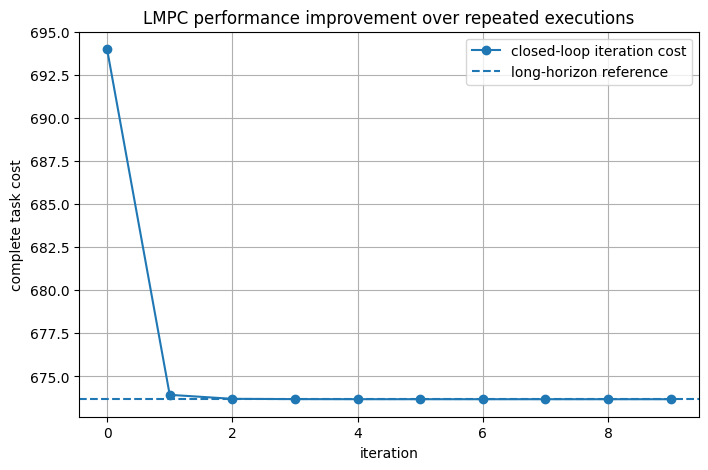

seed cost: 693.9923723414192
last LMPC cost: 673.676705720395
long-horizon reference: 673.6766534499407
final gap: 5.2270454375502595e-05


In [18]:
all_iteration_costs = np.array(
    [J_seed[0]]
    + [record["cost"] for record in iterations]
)

plt.figure()
plt.plot(
    np.arange(len(all_iteration_costs)),
    all_iteration_costs,
    "-o",
    label="closed-loop iteration cost",
)
plt.axhline(
    reference_cost,
    linestyle="--",
    label="long-horizon reference",
)
plt.xlabel("iteration")
plt.ylabel("complete task cost")
plt.title("LMPC performance improvement over repeated executions")
plt.legend()
plt.show()

print("seed cost:", all_iteration_costs[0])
print("last LMPC cost:", all_iteration_costs[-1])
print("long-horizon reference:", reference_cost)
print("final gap:", all_iteration_costs[-1] - reference_cost)


## XV.2 What is guaranteed and what is observed?

Under the standard deterministic repetitive-task LMPC assumptions, the previous successful
trajectory remains a feasible candidate for the next iteration, which supports a non-increasing
iteration-cost result.

In this example that behavior is visible numerically:

$$
J^{j+1}(x_S)\le J^j(x_S).
$$

This is different from claiming that every LMPC formulation must converge to the unique global
infinite-horizon optimum.


In [19]:
cost_differences = np.diff(all_iteration_costs)

print("iteration-to-iteration cost changes:")
print(cost_differences)

print("largest increase:", np.max(cost_differences))


iteration-to-iteration cost changes:
[-20.060788  -0.231937  -0.017133  -0.003817  -0.001224  -0.00046
  -0.000193  -0.000086  -0.000027]
largest increase: -2.6669017415770213e-05


<a id="part-16"></a>
# Part XVI — How the trajectories change

## XVI.1 Phase-plane evolution


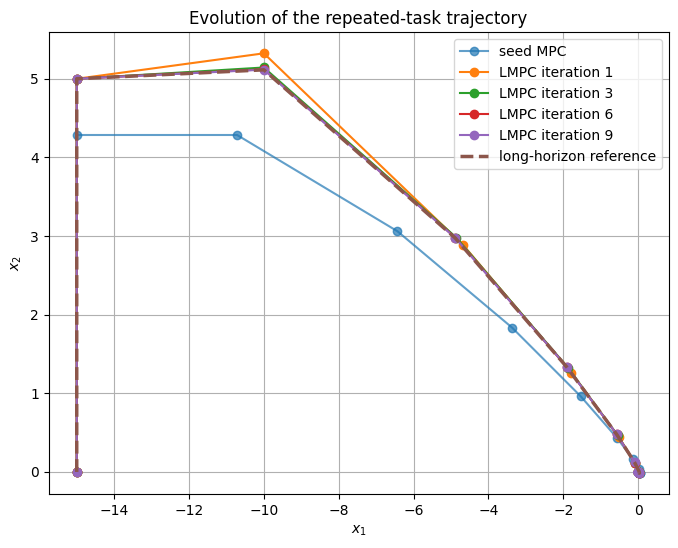

In [20]:
plt.figure(figsize=(8, 6))

plt.plot(
    X_seed[:, 0],
    X_seed[:, 1],
    "-o",
    alpha=0.7,
    label="seed MPC",
)

for idx in [0, 2, 5, 8]:
    record = iterations[idx]
    plt.plot(
        record["X"][:, 0],
        record["X"][:, 1],
        "-o",
        label=f"LMPC iteration {idx+1}",
    )

plt.plot(
    reference.X[:, 0],
    reference.X[:, 1],
    "--",
    linewidth=2.5,
    label="long-horizon reference",
)

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Evolution of the repeated-task trajectory")
plt.legend()
plt.show()


## XVI.2 Control evolution


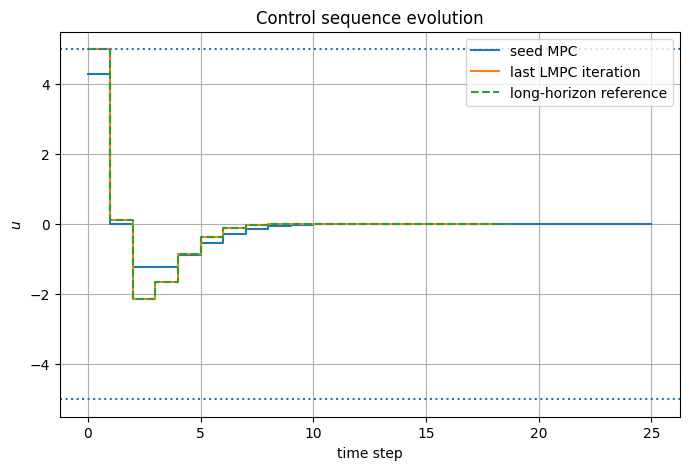

In [21]:
plt.figure()

plt.step(
    np.arange(len(U_seed)),
    U_seed[:, 0],
    where="post",
    label="seed MPC",
)

plt.step(
    np.arange(len(iterations[-1]["U"])),
    iterations[-1]["U"][:, 0],
    where="post",
    label="last LMPC iteration",
)

plt.step(
    np.arange(len(reference.U)),
    reference.U[:, 0],
    where="post",
    linestyle="--",
    label="long-horizon reference",
)

plt.axhline(5.0, linestyle=":")
plt.axhline(-5.0, linestyle=":")

plt.xlabel("time step")
plt.ylabel(r"$u$")
plt.title("Control sequence evolution")
plt.legend()
plt.show()


<a id="part-17"></a>
# Part XVII — Safe-set growth in the state plane

## XVII.1 Convex hull of accumulated successful data


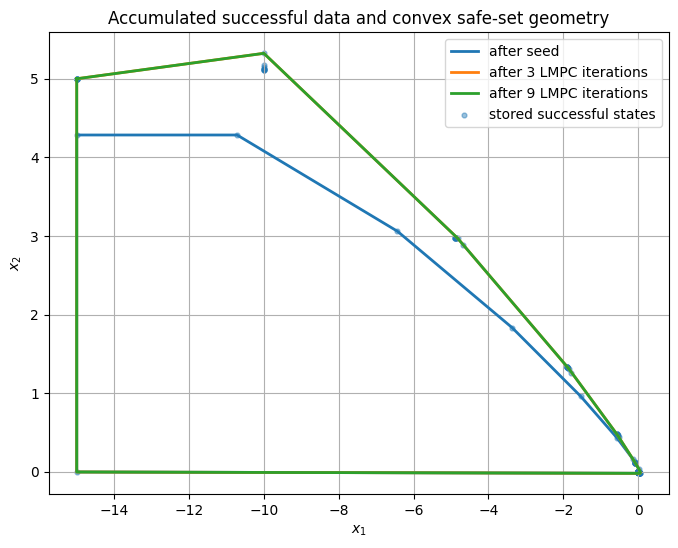

In [22]:
def safe_hull_points(trajectory_list):
    points = [np.zeros(2)]

    for X in trajectory_list:
        points.extend(X[:-1])

    points = np.asarray(points, float)
    points = np.unique(np.round(points, 10), axis=0)
    return points


def draw_hull(ax, points, label, linewidth=2):
    if len(points) < 3:
        return

    hull = ConvexHull(points)
    cycle = np.r_[hull.vertices, hull.vertices[0]]

    ax.plot(
        points[cycle, 0],
        points[cycle, 1],
        linewidth=linewidth,
        label=label,
    )


seed_points = safe_hull_points([X_seed])

mid_points = safe_hull_points(
    [X_seed]
    + [iterations[k]["X"] for k in range(3)]
)

final_points = safe_hull_points(
    [X_seed]
    + [record["X"] for record in iterations]
)

plt.figure(figsize=(8, 6))
ax = plt.gca()

draw_hull(ax, seed_points, "after seed")
draw_hull(ax, mid_points, "after 3 LMPC iterations")
draw_hull(ax, final_points, "after 9 LMPC iterations")

ax.scatter(
    final_points[:, 0],
    final_points[:, 1],
    s=12,
    alpha=0.45,
    label="stored successful states",
)

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_title("Accumulated successful data and convex safe-set geometry")
ax.legend()
plt.show()


## XVII.2 Safe-set geometry is only half of the learning

New trajectories can enlarge or reshape the safe-state hull.

But LMPC also learns better **cost-to-go values**.

Even when the hull changes very little near convergence, improved terminal values can still alter
the short-horizon decision.


<a id="part-18"></a>
# Part XVIII — Stored cost-to-go values

## XVIII.1 Backward recursion

The cost-to-go of each successful trajectory is computed backward:

$$
J_T=0,
$$

$$
\boxed{
J_t=h(x_t,u_t)+J_{t+1}.
}
$$

In the code, `trajectory_cost_to_go` implements this recursion, and `lmpc.safe_data()` returns
the resulting values, aligned with the rows of $S$, as the vector $V$ in the terminal cost
$\lambda^\top V$.

This resembles dynamic programming, but the values come from realized stored trajectories rather
than solving the Bellman optimality equation over the full state space.


In [23]:
J_last = trajectory_cost_to_go(
    iterations[-1]["X"],
    iterations[-1]["U"],
    Q,
    R,
    Q1,
)

residuals = []

for k in range(len(iterations[-1]["U"])):
    residuals.append(
        J_last[k]
        - stage_cost(
            iterations[-1]["X"][k],
            iterations[-1]["U"][k],
            Q,
            R,
            Q1,
        )
        - J_last[k+1]
    )

print(
    "maximum backward recursion residual:",
    np.max(np.abs(residuals))
)


maximum backward recursion residual: 2.842170943040401e-14


<a id="part-19"></a>
# Part XIX — What exactly is learned?

## XIX.1 The plant model is not learned here

The matrices $A$ and $B$ remain known and are used explicitly in every online optimization.

The learned information is:

1. safe terminal geometry;
2. successful continuation inputs;
3. terminal cost-to-go information.

This is data-driven but not model-free.


## XIX.2 LMPC is not DQN

A DQN learns an action-value approximation, commonly with a neural network and temporal-difference
updates.

This LMPC instead:

- keeps an explicit dynamics model;
- keeps explicit constraints;
- solves an optimization online;
- uses data to build terminal ingredients.

The methods are conceptually related through value information, but they are not the same
algorithmic framework.


## XIX.3 LMPC versus iterative learning control

Both exploit repetition.

Classical ILC often updates a trial-indexed feedforward/input signal from one execution to the next.

LMPC instead inserts learned trajectory information into a constrained receding-horizon optimal
control problem.

Its distinctive object is the learned terminal set/value pair.


<a id="part-20"></a>
# Part XX — Do different initializations converge to the same solution?

## XX.1 A natural question

LMPC only needs an initial **feasible successful trajectory**.

That trajectory may come from MPC, LQR, a human demonstration, or another controller.

Does every feasible initialization necessarily converge to the same final trajectory?

In general,

$$
\boxed{
\text{no universal global-optimum guarantee follows merely from feasibility.}
}
$$

The answer depends on task structure, convexity, stored data, controller formulation, and the
assumptions of the particular LMPC result.

This simple convex example may empirically produce very similar limiting behavior from different
reasonable seeds, but that observation is not a general theorem.


<a id="part-21"></a>
# Part XXI — Time-varying safe sets and data growth

## XXI.1 Why stored-data management matters

If every state from every successful iteration is retained, the number of barycentric variables
grows with the total number of samples.

One remedy is to use time-varying subsets of the stored data, for example

$$
TS_t^{l,j}
=
\left(
\bigcup_{i=l}^{j}
\bigcup_{s=t}^{T_i}
\{x^i[s]\}
\right)
\cup
\mathcal O.
$$

This subset keeps only iterations $l,\ldots,j$ and, from each of them, only the states visited at
time $t$ or later. The controller in this notebook uses only the iteration window, with the most
recent four trajectories (XIV.2), and keeps all time indices.

Any such subset creates a practical trade-off between richer data and smaller online optimization
problems.


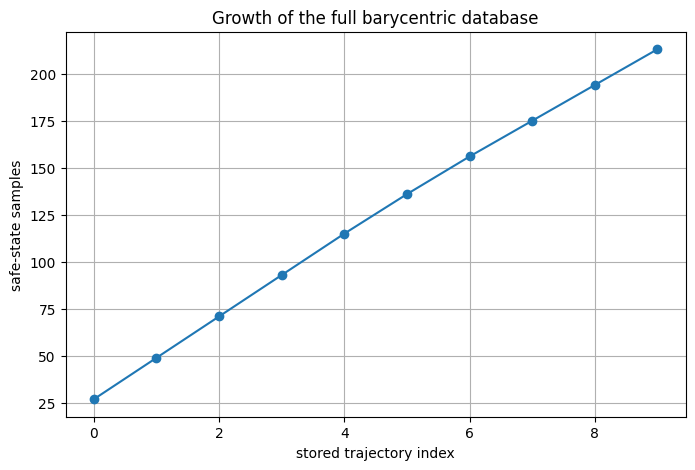

full database size after all iterations: 213
online active window: most recent 4 trajectories + target


In [24]:
full_safe_sizes = []

for j in range(len(lmpc.trajectories)):
    size = 1
    for X in lmpc.trajectories[:j+1]:
        size += len(X) - 1
    full_safe_sizes.append(size)

plt.figure()
plt.plot(np.arange(len(full_safe_sizes)), full_safe_sizes, "-o")
plt.xlabel("stored trajectory index")
plt.ylabel("safe-state samples")
plt.title("Growth of the full barycentric database")
plt.show()

print("full database size after all iterations:", full_safe_sizes[-1])
print("online active window: most recent 4 trajectories + target")


<a id="part-22"></a>
# Part XXII — What the experiment establishes

## XXII.1 Supported conclusions

The numerical example shows that:

- the short-horizon seed is feasible but more expensive;
- successful data provide terminal safe geometry and cost-to-go information;
- the LMPC terminal state satisfies a barycentric safe-set constraint;
- repeated executions reduce the complete task cost;
- the learned trajectories approach the long-horizon reference;
- the modeled constraints remain satisfied.


## XXII.2 Unsupported conclusions

This notebook alone does not establish:

- robustness to disturbances;
- robustness to model mismatch;
- safety of arbitrary nonlinear convexification;
- global-optimality convergence for every LMPC problem;
- model-free learning;
- transfer to unrelated initial conditions without additional analysis.


<a id="part-23"></a>
# Part XXIII — Common pitfalls

## XXIII.1 Pitfall: every stored state is optimal

No. Stored states are safe because they belong to successful trajectories. A successful trajectory
may be very suboptimal.

---

## XXIII.2 Pitfall: the convex hull is always safe

No. The invariance proof of III.3 relies on linear dynamics and convex constraints.

---

## XXIII.3 Pitfall: the terminal value is a neural network

Not here. It is built from stored roll-out costs and barycentric interpolation.

---

## XXIII.4 Pitfall: safe-set growth alone explains learning

No. The learned value/cost-to-go is equally important.

---

## XXIII.5 Pitfall: the long-horizon reference proves the exact infinite-horizon optimum

No. It is a numerical finite-horizon proxy whose convergence is checked.

---

## XXIII.6 Pitfall: a three-step horizon only sees three steps ahead

Only the explicit prediction is three steps long. The seed MPC and LMPC both use
$N_{\mathrm{MPC}}=N_{\mathrm{LMPC}}=3$, but LMPC adds the terminal constraint $x_N=S^\top\lambda$,
which links the prediction to stored continuations that reach the target, and the terminal cost
$\lambda^\top V$, which prices the remainder of the task. That is why LMPC improves on the seed with
the same horizon (VIII.4).

---

## XXIII.7 Pitfall: LMPC is reinforcement learning simply because it learns from data

In this notebook, LMPC is model-based predictive control with terminal ingredients learned from
successful closed-loop data (Part XIX).


<a id="part-24"></a>
# Part XXIV — Check your understanding

Try to answer each question before opening its answer.

**1. What is the sampled safe set?**

<details>
<summary>Answer</summary>

The union of states visited by successful previous iterations, together with the target set.

</details>

**2. Why is a sampled state safe?**

<details>
<summary>Answer</summary>

Because replaying its stored continuation input takes the system to the next state of a successful
trajectory and, step by step, to the target.

</details>

**3. What is the convex safe set?**

<details>
<summary>Answer</summary>

The convex hull of the sampled safe set:

$$
CS^j=\operatorname{conv}(SS^j).
$$

</details>

**4. Why is it control invariant in this example?**

<details>
<summary>Answer</summary>

Linearity maps convex combinations of safe state/input pairs to convex combinations of safe
successors, and the state/input constraints are convex.

</details>

**5. What is stored besides the state?**

<details>
<summary>Answer</summary>

A continuation input/successor and a realized cost-to-go.

</details>

**6. What does $x_N=S^\top\lambda$ mean?**

<details>
<summary>Answer</summary>

Together with $\lambda\ge0$ and $\mathbf1^\top\lambda=1$, it places the terminal prediction inside
the convex hull of the successful stored states, which are the rows of $S$.

</details>

**7. What does $\lambda^\top V$ mean?**

<details>
<summary>Answer</summary>

The learned terminal value obtained by barycentric interpolation of stored costs-to-go.

</details>

**8. What is actually learned?**

<details>
<summary>Answer</summary>

Terminal safe geometry, continuation information, and terminal cost-to-go; not the system matrices,
which are known in this example.

</details>

**9. Why is one feasible trajectory enough to start?**

<details>
<summary>Answer</summary>

It provides at least one complete admissible continuation from the repeated initial condition to
the target, together with safe states and costs-to-go.

</details>

**10. Why can a horizon-three LMPC outperform the horizon-three seed MPC?**

<details>
<summary>Answer</summary>

The learned terminal set and value communicate information about safe and costly behavior beyond
the explicit three-step prediction window.

</details>

**11. Why is the $\ell_1$ term represented with epigraph variables?**

<details>
<summary>Answer</summary>

Absolute values can be represented by linear inequalities $-e_i\le z_i\le e_i$, $e_i\ge0$, while
minimizing $\sum e_i$, so the online problem stays a QP.

</details>

**12. Does monotonic iteration cost imply global optimality?**

<details>
<summary>Answer</summary>

No. Performance improvement and convergence to a global optimum are different statements.

</details>

**13. Why does the QP grow with experience?**

<details>
<summary>Answer</summary>

Each active safe-state sample contributes a barycentric variable.

</details>

**14. Why use a limited trajectory window?**

<details>
<summary>Answer</summary>

It bounds the size of the online QP while retaining recent successful continuations, including the
previous iteration, which the cost-improvement argument of XV.2 needs.

</details>


<a id="part-25"></a>
# Part XXV — Exercises

### Exercise 1 — sampled safe-set invariance

Prove

$$
x\in SS^j
\Longrightarrow
\exists u\in\mathcal U:
f(x,u)\in SS^j.
$$

State the required target-set assumption.

---

### Exercise 2 — convex invariance

For $x^+=Ax+Bu$, prove control invariance of $CS^j$ under convex constraints.

Identify where linearity and convexity enter.

---

### Exercise 3 — barycentric LP

Compute $V_c^1(2.5)$ by hand in the one-dimensional example.

---

### Exercise 4 — dominated data

Add a worse trajectory through an already sampled state and explain how the sampled minimum and
convex envelope treat it.

---

### Exercise 5 — stage cost by hand

For

$$
x=[-2,1]^\top,
\qquad
u=0.5,
$$

compute the stage cost $h(x,u)$ of VIII.2 by hand.

---

### Exercise 6 — epigraph

Prove the epigraph representation of $\|z\|_1$.

---

### Exercise 7 — horizon

Repeat the seed MPC experiment with $N=2,3,5$ and compare complete closed-loop task costs.

---

### Exercise 8 — different feasible seed

Generate another successful seed and compare the LMPC learning curve.

Does the experiment prove initialization independence?

---

### Exercise 9 — database size

Compare all-data versus recent-trajectory safe sets and record solve time and iteration cost.

---

### Exercise 10 — model mismatch

If the real system is

$$
x^+=(A+\Delta A)x+Bu,
$$

which line in the convex-invariance proof fails?

---

### Exercise 11 — nonlinear counterexample

Give a nonlinear $f(x,u)$ for which convex combinations do not propagate linearly.

---

### Exercise 12 — classical MPC versus LMPC terminal ingredients

Compare the classical pair

$$
(\mathcal X_f,p)
$$

with the learned pair

$$
(CS^j,V_c^j).
$$

Which roles are analogous, and where does the information come from?


<a id="part-26"></a>
# Part XXVI — References

- U. Rosolia and F. Borrelli, “Learning Model Predictive Control for Iterative Tasks. A Data-Driven
  Control Framework,” *IEEE Transactions on Automatic Control*, 63(7), 1883–1896, 2018,
  DOI 10.1109/TAC.2017.2753460.
- F. Borrelli, A. Bemporad, and M. Morari,
  *Predictive Control for Linear and Hybrid Systems*, Cambridge University Press, 2017.
- J. B. Rawlings, D. Q. Mayne, and M. M. Diehl,
  *Model Predictive Control: Theory, Computation, and Design*, 2nd ed., 2022.

Implementation note: the long-horizon reference of Part IX uses $N=20$ after a horizon-convergence
check instead of a very long horizon such as $N=1000$, so that the notebook remains lightweight and
solver-independent.
